In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(".."))

import gymnasium as gym
from core.env.types import ObserveType, RewardOptions

num_envs = 16
total_timesteps = 1_000_000

env = gym.make_vec(
    "Snake-v0",
    num_envs=num_envs,
    vectorization_mode="sync",
    width=20,
    height=20,
    obs_type=ObserveType.VEC_11,
    num_apples=3,
    num_obstacles=15,
    seed=42,
    reward_options=RewardOptions(
        eats_apple=24.0,
        penalty_step=-0.01,
        penalty_loop=-0.1,
        death_wall=-20.0,
        death_self=-20.0,
        shaping_closer=0.1,
        shaping_further=-0.1,
        complete=100.0,
    ),
)

In [ ]:
from agents.dqn.dqn_vec11 import DQNVec11Agent

agent_name = "dqn_snake_vec11"
agent = DQNVec11Agent(
    hidden_dim=256,
    learning_rate=1e-3,
    buffer_size=100000,
    batch_size=256,
    gamma=0.99,
    eps_init=1.0,
    explore_final_eps=0.01,
    exploration_fraction=0.6,
    learning_starts=1000,
    train_freq=1,
    device="auto",
    seed=42,
)

Starting parallel training for 1000000 timesteps...


Parallel Training: 100%|██████████| 1000000/1000000 [26:57<00:00, 618.27it/s, Avg Rwd (100)=410.87, Best=481.09, Eps=0.010]


Training completed. Collected 267916 episodes.


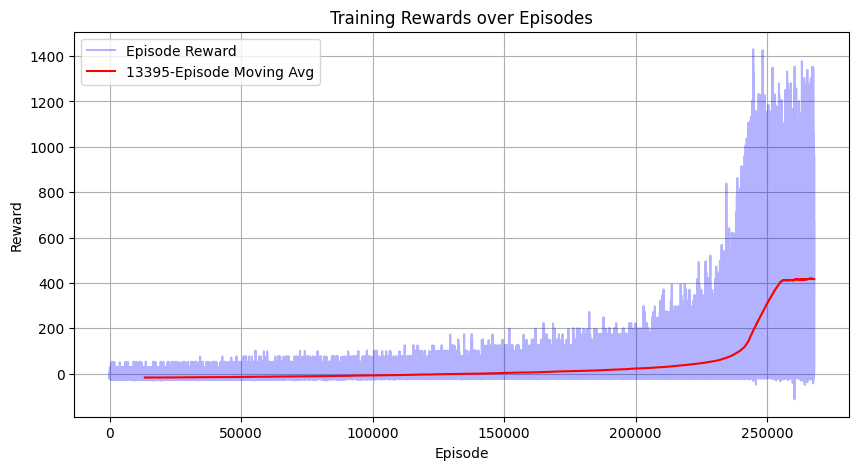

In [3]:
import pandas as pd

print(f"Starting parallel training for {total_timesteps} timesteps...")
metrics = agent.train(env, total_timesteps=total_timesteps)

env.close()

print(f"Training completed. Collected {len(metrics['episode_rewards'])} episodes.")

# Plot rewards
episodes = np.arange(len(metrics["episode_rewards"]))
rewards = metrics["episode_rewards"]

plt.figure(figsize=(10, 5))
plt.plot(episodes, rewards, alpha=0.2, color="blue", label="Episode Reward")

# Plot Exponential Moving Average (EWMA)
if len(rewards) > 0:
    # Alpha ~0.05 corresponds roughly to a window of 20 episodes
    # Smaller alpha = smoother curve but more lag
    ewma = pd.Series(rewards).ewm(alpha=0.01).mean()
    plt.plot(episodes, ewma, color="red", linewidth=2, label="EWMA Smoothing")

plt.title("Training Rewards over Episodes")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.grid(True)
plt.show()